# 1.Libraries import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

# 2. Regimes distribution

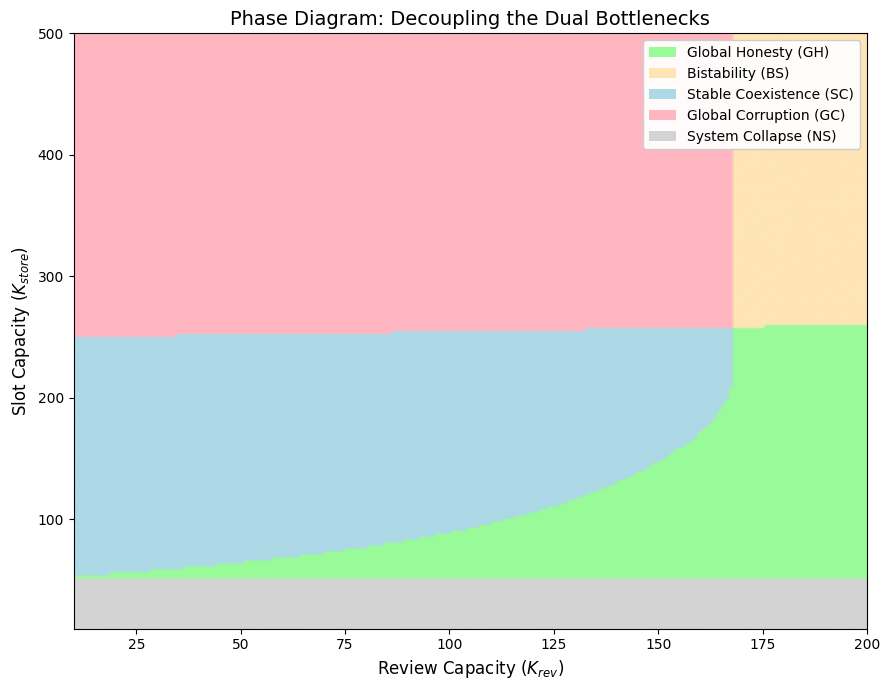

In [ ]:

# ==========================================
# 1. Core Model Functions
# ==========================================
def soft_min(a, b, k):
    """Smooth approximation of min(a, b)"""
    return -np.log(np.exp(-k * a) + np.exp(-k * b)) / k

def get_model_states(x, p):
    k = p.get('smoothness', 15)

    # 1. Volume
    V_total = p['N'] * (1 - (1 - p['alpha']) * x)

    # 2. Review Bottleneck (Eta)
    # Clip to [0, 1] to avoid negative probabilities due to soft_min approximation
    eta_val = soft_min(1.0, p['K_rev'] / V_total, k)
    eta = np.clip(eta_val, 0.0, 1.0)

    pi_0 = 1 - eta * (1 - p['lam'])
    pi_1 = 1 - eta * p['epsilon']

    # 3. Storage Bottleneck (Rho)
    V_G = p['N'] * p['alpha']
    V_B = p['N'] * (1 - p['alpha']) * (1 - x)
    M = V_G * pi_1 + V_B * pi_0

    # Clip to [0, 1]
    rho_val = soft_min(1.0, p['K_store'] / M, k)
    rho_bar = np.clip(rho_val, 0.0, 1.0)

    # 4. Payoffs
    # Net Utility of Bad Paper
    Pi_bad = p['r'] * rho_bar * pi_0 - p['c']
    # Net Utility of Good Paper (for Participation Constraint)
    Pi_good = p['r'] * rho_bar * pi_1 - p['c']

    return Pi_bad, Pi_good, rho_bar, eta

def classify_regime_map(p):
    """
    Classify the regime for the Phase Diagram.
    0: GH, 1: GC, 2: BS, 3: SC, 4: NS
    """
    # Check Boundary Payoffs

    # x=1 (Honesty Boundary)
    Pi_bad_1, Pi_good_1, _, _ = get_model_states(0.999, p)

    # Check viability (Participation Constraint)
    # If honest authors expect negative utility even at x=1 (clean system),
    # the system is non-viable (No Submission).
    if Pi_good_1 < 0:
        return 4 # System Collapse (NS) - Gray

    # Stability of x=1
    # If Pi_bad(1) < 0, cheating is unprofitable -> x tends to 1 -> STABLE
    # If Pi_bad(1) > 0, cheating is profitable -> x tends to 0 -> UNSTABLE
    one_stable = (Pi_bad_1 < 0)

    # x=0 (Corruption Boundary)
    Pi_bad_0, _, _, _ = get_model_states(0.001, p)
    # Stability of x=0
    # If Pi_bad(0) > 0, cheating is profitable -> x tends to 0 -> STABLE
    # If Pi_bad(0) < 0, cheating is unprofitable -> x tends to 1 -> UNSTABLE
    zero_stable = (Pi_bad_0 > 0)

    # Determine Regime based on boundary stability
    if one_stable and zero_stable:
        return 2 # Bistability (Yellow)
    elif one_stable and not zero_stable:
        return 0 # Global Honesty (Green)
    elif not one_stable and zero_stable:
        return 1 # Global Corruption (Red)
    elif not one_stable and not zero_stable:
        return 3 # Stable Coexistence (Blue)

    return -1

# ==========================================
# 2. Generate Phase Diagram Data
# ==========================================
# Parameter Selection Logic:
# To see all 4 regimes, we need a setup where:
# 1. Uncongested cheating is NOT profitable (r*lam < c) -> Allows Green/Yellow
# 2. Review collapse is possible (K_rev < N*alpha) -> Allows Red/Blue
# 3. Storage collapse is possible -> Allows Blue/Green transition
#
# Selected Set: r=100, c=25, lam=0.1
# r*lam = 10 < 25 -> Pi_bad(1) < 0 if review is perfect.
# But if review fails (eta -> 0, pi0 -> 1), Pi_bad -> 100*1*1 - 25 = 75 > 0.
# So we can get 1 Unstable if K_rev is low.
map_params = {
    'N': 1000,
    'alpha': 0.2,
    'r': 100,
    'c': 25,
    'lam': 0.1,
    'epsilon': 0.05,
    'smoothness': 15
}

res = 200 # High resolution for clean boundaries
k_rev_vals = np.linspace(10, 200, res)
k_store_vals = np.linspace(10, 500, res)
regime_map = np.zeros((res, res))

for i, ks in enumerate(k_store_vals):
    for j, kr in enumerate(k_rev_vals):
        p = map_params.copy()
        p['K_rev'] = kr
        p['K_store'] = ks
        regime_map[i, j] = classify_regime_map(p)

# ==========================================
# 3. Plotting
# ==========================================
plt.figure(figsize=(9, 7))

# Colormap: 0=Green, 1=Red, 2=Yellow, 3=Blue, 4=Gray
# Order in map values: 0, 1, 2, 3, 4
# ListedColormap needs colors for integers 0, 1, 2, 3, 4
colors = ['#98FB98', '#FFB6C1', '#FFE4B5', '#ADD8E6', '#D3D3D3']
cmap = ListedColormap(colors)

plt.imshow(regime_map, origin='lower',
           extent=[k_rev_vals.min(), k_rev_vals.max(), k_store_vals.min(), k_store_vals.max()],
           aspect='auto', cmap=cmap)

plt.xlabel(r'Review Capacity ($K_{rev}$)', fontsize=12)
plt.ylabel(r'Slot Capacity ($K_{store}$)', fontsize=12)
plt.title('Phase Diagram: Decoupling the Dual Bottlenecks', fontsize=14)

# Custom Legend
legend_elements = [
    Patch(facecolor='#98FB98', label='Global Honesty (GH)'),
    Patch(facecolor='#FFE4B5', label='Bistability (BS)'),
    Patch(facecolor='#ADD8E6', label='Stable Coexistence (SC)'),
    Patch(facecolor='#FFB6C1', label='Global Corruption (GC)'),
    Patch(facecolor='#D3D3D3', label='System Collapse (NS)')
]
plt.legend(handles=legend_elements, loc='upper right', framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.savefig('regime_map_final.pdf', dpi=300)
plt.show()

# 3.Hysteresis Loop and Quality Collapse

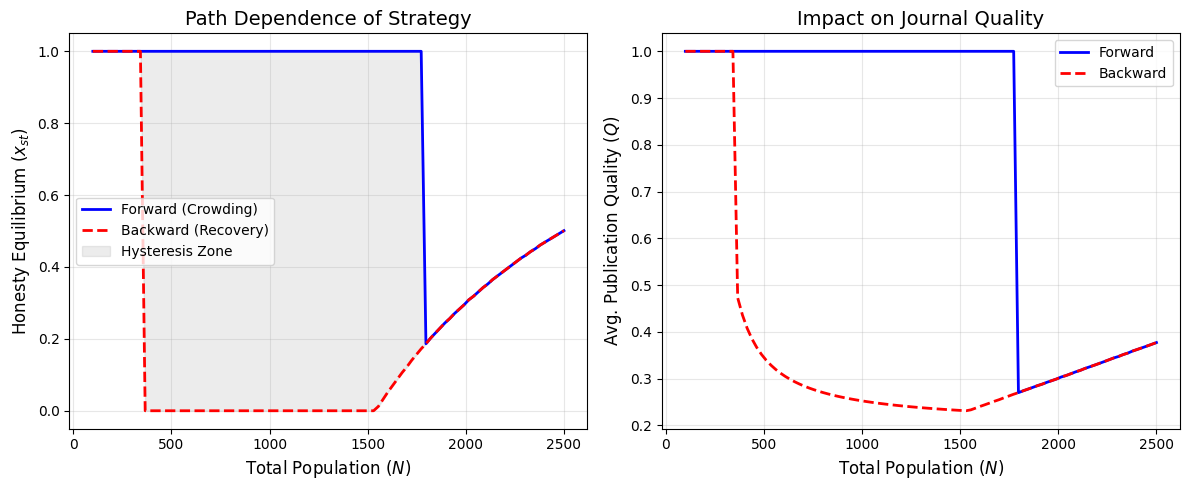

In [ ]:

# ==========================================
# 1. Core Model Functions
# ==========================================
def soft_min(a, b, k):
    """Smooth approximation of min(a, b)"""
    return -np.log(np.exp(-k * a) + np.exp(-k * b)) / k

def get_model_states(x, p):
    """
    Calculate intermediate model states (Eta, Rho, Payoffs).
    Includes np.clip to ensure probabilities stay in [0, 1].
    """
    k = p.get('smoothness', 15)

    # 1. Volume
    V_total = p['N'] * (1 - (1 - p['alpha']) * x)

    # 2. Review Bottleneck (Eta)
    # Fix: Clip to avoid negative probabilities from soft_min approximation
    eta_val = soft_min(1.0, p['K_rev'] / V_total, k)
    eta = np.clip(eta_val, 0.0, 1.0)

    pi_0 = 1 - eta * (1 - p['lam'])
    pi_1 = 1 - eta * p['epsilon']

    # 3. Storage Bottleneck (Rho)
    V_G = p['N'] * p['alpha']
    V_B = p['N'] * (1 - p['alpha']) * (1 - x)
    M = V_G * pi_1 + V_B * pi_0

    # Fix: Clip to avoid negative probabilities
    rho_val = soft_min(1.0, p['K_store'] / M, k)
    rho_bar = np.clip(rho_val, 0.0, 1.0)

    # 4. Payoffs
    # Net Utility of Bad Paper
    Pi_bad = p['r'] * rho_bar * pi_0 - p['c']
    # Net Utility of Good Paper (not used for dynamics but useful for checks)
    Pi_good = p['r'] * rho_bar * pi_1 - p['c']

    return Pi_bad, Pi_good, rho_bar, eta

def get_dxdt(x, p):
    """Replicator dynamics velocity field."""
    Pi_bad, _, _, _ = get_model_states(x, p)
    return -x * (1 - x) * (1 - p['alpha']) * Pi_bad

# ==========================================
# 2. Hysteresis Simulation Logic
# ==========================================
# Use Baseline Set A (Bistable Regime)
hyst_params = {
    'N': 1000, # Variable to scan
    'alpha': 0.2,
    'K_rev': 300,
    'K_store': 400,
    'r': 100,
    'c': 25,
    'lam': 0.1,
    'epsilon': 0.05,
    'smoothness': 15
}

n_vals = np.linspace(100, 2500, 100)
x_fwd, x_bwd = [], []
q_fwd, q_bwd = [], []

def get_stable_root_hyst(p, initial_guess):
    """
    Find the stable equilibrium closest to the initial_guess (Adiabatic Continuation).
    """
    x_grid = np.linspace(0, 1, 500)
    dxdt_vals = get_dxdt(x_grid, p)

    roots = []

    # Check Boundary Stability: x=0
    # If cheating profitable (Pi_bad > 0) -> x decreases to 0 -> 0 is Stable
    pb0, _, _, _ = get_model_states(0.001, p)
    if pb0 > 0: roots.append(0.0)

    # Check Boundary Stability: x=1
    # If cheating unprofitable (Pi_bad < 0) -> x increases to 1 -> 1 is Stable
    pb1, _, _, _ = get_model_states(0.999, p)
    if pb1 < 0: roots.append(1.0)

    # Check Internal Stable Roots (slope crosses from + to -)
    signs = np.sign(dxdt_vals)
    sign_changes = np.where(np.diff(signs))[0]
    for idx in sign_changes:
        if dxdt_vals[idx] > 0 and dxdt_vals[idx+1] < 0:
            roots.append(x_grid[idx])

    # Fallback if no roots found (rare)
    if not roots:
        return 0.0 if initial_guess < 0.5 else 1.0

    # Pick the root closest to the history (Adiabatic condition)
    return min(roots, key=lambda x: abs(x-initial_guess))

def calculate_quality(x, p):
    """Calculate Average Publication Quality Q(x)"""
    pb, pg, rho, eta = get_model_states(x, p)
    pi_0 = 1 - eta * (1 - p['lam'])
    pi_1 = 1 - eta * p['epsilon']

    passed_good = p['N'] * p['alpha'] * pi_1
    passed_bad = p['N'] * (1 - p['alpha']) * (1 - x) * pi_0

    total = passed_good + passed_bad
    if total <= 1e-9: return 1.0 # Handle division by zero
    return passed_good / total

# --- Forward Scan (Crowding) ---
curr_x = 1.0 # Start from Honesty
for n in n_vals:
    p = hyst_params.copy()
    p['N'] = n
    root = get_stable_root_hyst(p, curr_x)
    x_fwd.append(root)
    q_fwd.append(calculate_quality(root, p))
    curr_x = root

# --- Backward Scan (Recovery) ---
# Start from where Forward ended (Corruption)
curr_x = x_fwd[-1]
# Fix: Iterate n_vals in reverse, but append results correctly
for n in n_vals[::-1]:
    p = hyst_params.copy()
    p['N'] = n
    root = get_stable_root_hyst(p, curr_x)
    x_bwd.append(root)
    q_bwd.append(calculate_quality(root, p))
    curr_x = root

# Fix: Reverse the results to align with n_vals (increasing order) for plotting
x_bwd = x_bwd[::-1]
q_bwd = q_bwd[::-1]

# ==========================================
# 3. Plotting
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: State x*
ax1.plot(n_vals, x_fwd, 'b-', lw=2, label='Forward (Crowding)')
ax1.plot(n_vals, x_bwd, 'r--', lw=2, label='Backward (Recovery)')
ax1.fill_between(n_vals, x_fwd, x_bwd, color='gray', alpha=0.15, label='Hysteresis Zone')

ax1.set_xlabel('Total Population ($N$)', fontsize=12)
ax1.set_ylabel('Honesty Equilibrium ($x_{st}$)', fontsize=12)
ax1.set_title('Path Dependence of Strategy', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Quality Q
ax2.plot(n_vals, q_fwd, 'b-', lw=2, label='Forward')
ax2.plot(n_vals, q_bwd, 'r--', lw=2, label='Backward')

ax2.set_xlabel('Total Population ($N$)', fontsize=12)
ax2.set_ylabel('Avg. Publication Quality ($Q$)', fontsize=12)
ax2.set_title('Impact on Journal Quality', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# Save file
plt.savefig('hysteresis_combined.pdf', dpi=300)
plt.show()

# 4.Parameters effects

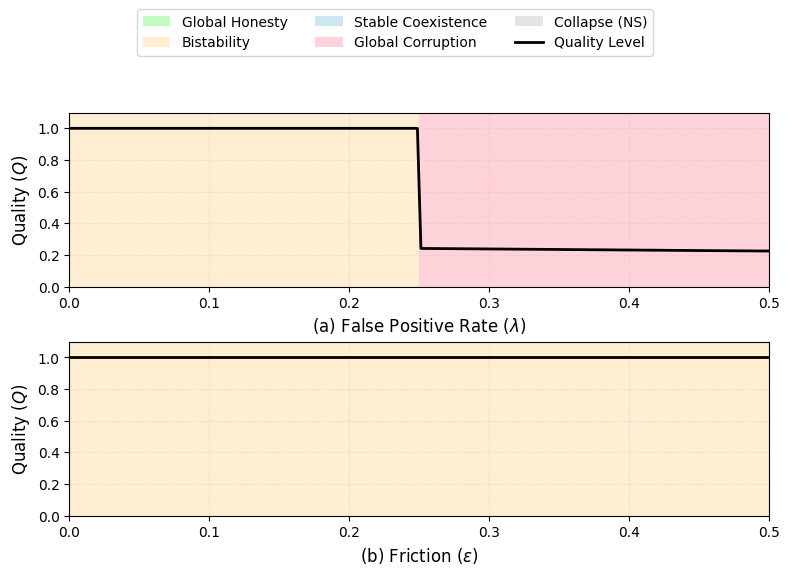

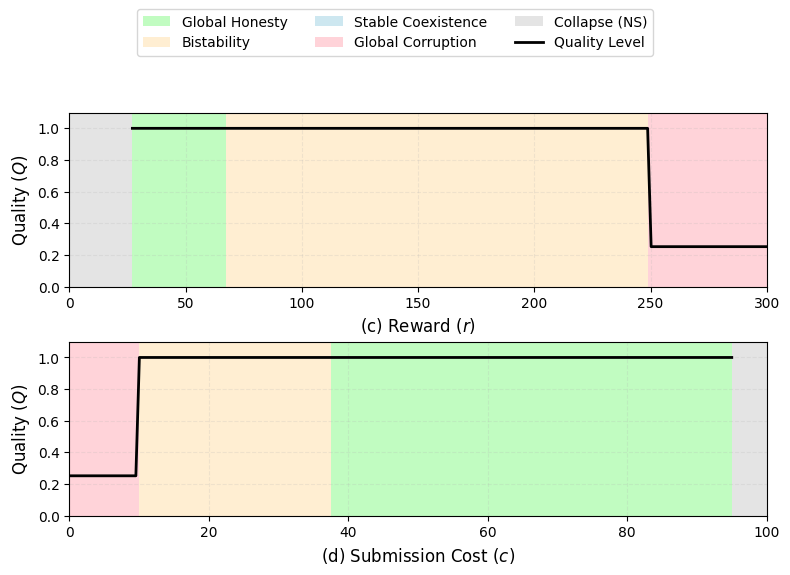

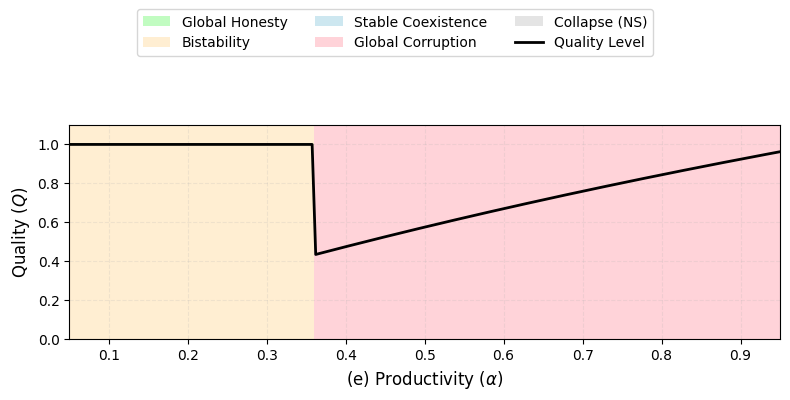

In [4]:


# ==========================================
# 1. Core Model Functions (Rigorous)
# ==========================================
def soft_min(a, b, k):
    return -np.log(np.exp(-k * a) + np.exp(-k * b)) / k

def get_model_states(x, p):
    k = p.get('smoothness', 15)
    # Volume
    V_total = p['N'] * (1 - (1 - p['alpha']) * x)
    # Review
    eta = np.clip(soft_min(1.0, p['K_rev'] / V_total, k), 0.0, 1.0)
    pi_0 = 1 - eta * (1 - p['lam'])
    pi_1 = 1 - eta * p['epsilon']
    # Storage
    V_G = p['N'] * p['alpha']
    V_B = p['N'] * (1 - p['alpha']) * (1 - x)
    M = V_G * pi_1 + V_B * pi_0
    rho_bar = np.clip(soft_min(1.0, p['K_store'] / M, k), 0.0, 1.0)
    # Payoffs
    Pi_bad = p['r'] * rho_bar * pi_0 - p['c']
    Pi_good = p['r'] * rho_bar * pi_1 - p['c']
    return Pi_bad, Pi_good, rho_bar, eta, pi_0, pi_1

def classify_regime_point(p):
    """
    Returns regime code:
    0: GH (Green), 1: GC (Red), 2: BS (Yellow), 3: SC (Blue), 4: NS (Gray)
    """
    # 1. Check Viability (Participation Constraint at Honest Equilibrium)
    Pi_bad_1, Pi_good_1, _, _, _, _ = get_model_states(0.999, p)
    if Pi_good_1 < 0:
        return 4 # NS

    # 2. Check Stability Boundaries
    one_stable = (Pi_bad_1 < 0)
    Pi_bad_0, _, _, _, _, _ = get_model_states(0.001, p)
    zero_stable = (Pi_bad_0 > 0)

    if one_stable and zero_stable: return 2 # BS
    if one_stable and not zero_stable: return 0 # GH
    if not one_stable and zero_stable: return 1 # GC
    if not one_stable and not zero_stable: return 3 # SC
    return 4 # Fallback

def get_quality_at_equilibrium(p):
    x_grid = np.linspace(0, 1, 500)
    dxdt = -x_grid * (1 - x_grid) * (1 - p['alpha']) * get_model_states(x_grid, p)[0]

    roots = []
    # Check boundaries
    pb0, _, _, _, _, _ = get_model_states(0.001, p)
    if pb0 > 0: roots.append(0.0)
    pb1, _, _, _, _, _ = get_model_states(0.999, p)
    if pb1 < 0: roots.append(1.0)
    # Internal
    signs = np.sign(dxdt)
    sign_changes = np.where(np.diff(signs))[0]
    for idx in sign_changes:
        if dxdt[idx] > 0 and dxdt[idx+1] < 0:
            roots.append(x_grid[idx])

    if not roots: return 0.0 # Should be covered by NS
    x_star = max(roots)

    # Calculate Q
    _, _, _, _, pi_0, pi_1 = get_model_states(x_star, p)
    pass_G = p['N'] * p['alpha'] * pi_1
    pass_B = p['N'] * (1 - p['alpha']) * (1 - x_star) * pi_0
    if (pass_G + pass_B) < 1e-9: return 0.0
    return pass_G / (pass_G + pass_B)

# ==========================================
# 2. Scanning Setup
# ==========================================
base_params = {
    'N': 1000, 'alpha': 0.2,
    'K_rev': 300, 'K_store': 400,
    'r': 100, 'c': 25,
    'lam': 0.1, 'epsilon': 0.05,
    'smoothness': 15
}

sweeps = [
    ('lam', r'(a) False Positive Rate ($\lambda$)', np.linspace(0, 0.5, 200)),
    ('epsilon', r'(b) Friction ($\epsilon$)', np.linspace(0, 0.5, 200)),
    ('r', r'(c) Reward ($r$)', np.linspace(0, 300, 200)),
    ('c', r'(d) Submission Cost ($c$)', np.linspace(0, 100, 200)),
    ('alpha', r'(e) Productivity ($\alpha$)', np.linspace(0.05, 0.95, 200))
]

# Splitting the sweeps into 3 parts (2, 2, 1)
sweeps_part1 = sweeps[:2] # a, b
sweeps_part2 = sweeps[2:4] # c, d
sweeps_part3 = sweeps[4:] # e

# ==========================================
# 3. Plotting Helper Function
# ==========================================
def plot_regime_strips(sweep_list, filename, figsize):
    fig, axes = plt.subplots(len(sweep_list), 1, figsize=figsize, sharey=True)
    # Ensure axes is iterable even if only 1 plot
    if len(sweep_list) == 1: axes = [axes]

    colors = ['#98FB98', '#FFB6C1', '#FFE4B5', '#ADD8E6', '#D3D3D3']
    cmap = ListedColormap(colors)

    for i, (param, label, vals) in enumerate(sweep_list):
        ax = axes[i]
        regime_strip = []
        quality_line = []

        for val in vals:
            p = base_params.copy()
            p[param] = val
            reg = classify_regime_point(p)
            regime_strip.append(reg)
            if reg == 4:
                quality_line.append(np.nan)
            else:
                quality_line.append(get_quality_at_equilibrium(p))

        regime_arr = np.array(regime_strip)[np.newaxis, :]
        ax.imshow(regime_arr, aspect='auto', cmap=cmap, vmin=0, vmax=4,
                  extent=[vals.min(), vals.max(), 0, 1.1], alpha=0.6)
        ax.plot(vals, quality_line, 'k-', lw=2, label='Avg. Quality ($Q$)')

        ax.set_xlabel(label, fontsize=12)
        ax.set_ylabel('Quality ($Q$)', fontsize=12)
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.2, linestyle='--')

    # Legend (same for all)
    legend_elements = [
        Patch(facecolor='#98FB98', label='Global Honesty', alpha=0.6),
        Patch(facecolor='#FFE4B5', label='Bistability', alpha=0.6),
        Patch(facecolor='#ADD8E6', label='Stable Coexistence', alpha=0.6),
        Patch(facecolor='#FFB6C1', label='Global Corruption', alpha=0.6),
        Patch(facecolor='#D3D3D3', label='Collapse (NS)', alpha=0.6),
        plt.Line2D([0], [0], color='k', lw=2, label='Quality Level')
    ]
    # Adjust legend position based on number of subplots
    bbox_y = 1.05 if len(sweep_list) > 1 else 1.15
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, bbox_y), ncol=3, fontsize=10)

    plt.tight_layout()
    # Adjust top margin to accommodate legend
    top_margin = 0.85 if len(sweep_list) > 1 else 0.80
    plt.subplots_adjust(top=top_margin)
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# 4. Generate Plots
# ==========================================
# Part 1: lambda, epsilon (2 plots)
plot_regime_strips(sweeps_part1, 'strategic_regimes_scan_part1.pdf', figsize=(8, 5.5))

# Part 2: r, c (2 plots)
plot_regime_strips(sweeps_part2, 'strategic_regimes_scan_part2.pdf', figsize=(8, 5.5))

# Part 3: alpha (1 plot)
plot_regime_strips(sweeps_part3, 'strategic_regimes_scan_part3.pdf', figsize=(8, 3.5))

# 5.Boundaries regimes

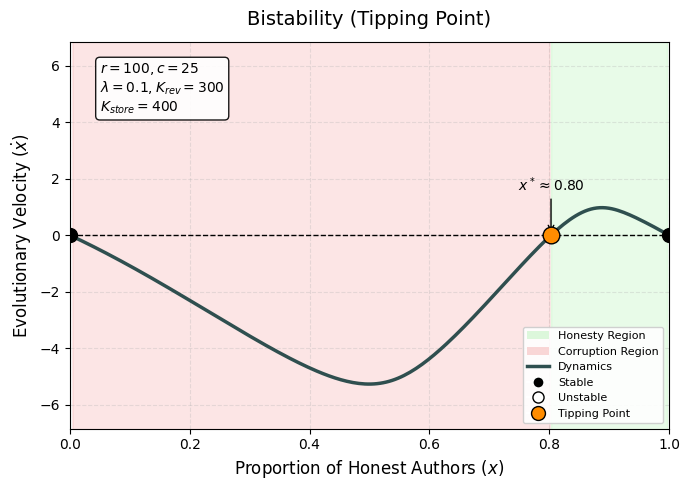

<Figure size 640x480 with 0 Axes>

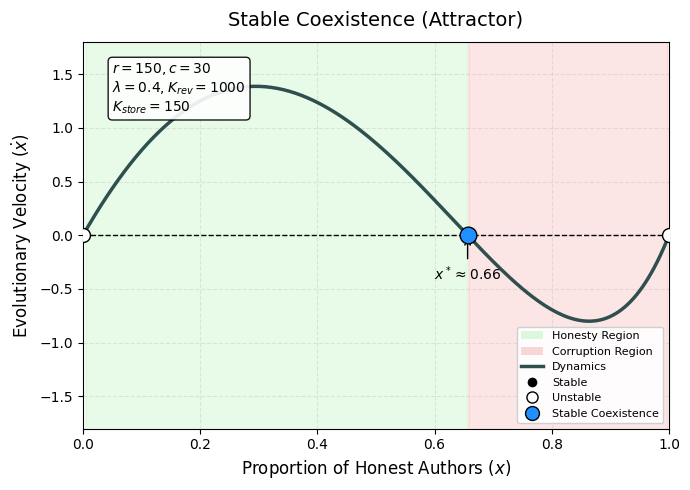

<Figure size 640x480 with 0 Axes>

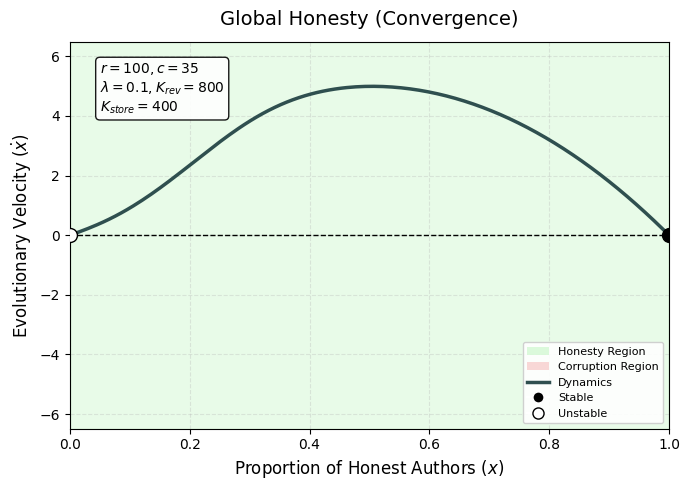

<Figure size 640x480 with 0 Axes>

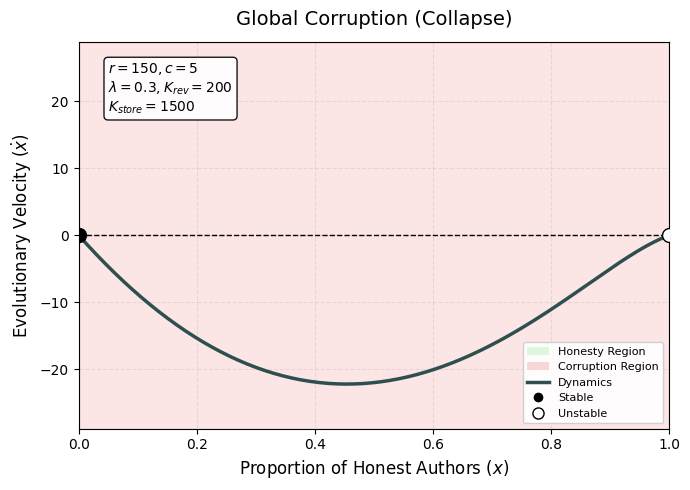

<Figure size 640x480 with 0 Axes>

In [ ]:

# ==========================================
# 1. Core Mathematical Model
# ==========================================
def soft_min(a, b, k):
    return -np.log(np.exp(-k * a) + np.exp(-k * b)) / k

def get_dxdt_curve(x_arr, p):
    k = p.get('smoothness', 15)
    y_vals = []

    for x in x_arr:
        # 1. Volume calculation
        V_total = p['N'] * (1 - (1 - p['alpha']) * x)

        # 2. Review Stage
        eta = np.clip(soft_min(1.0, p['K_rev'] / V_total, k), 0.0, 1.0)
        pi_0 = 1 - eta * (1 - p['lam'])
        pi_1 = 1 - eta * p['epsilon']

        # 3. Storage Stage
        V_G = p['N'] * p['alpha']
        V_B = p['N'] * (1 - p['alpha']) * (1 - x)
        M = V_G * pi_1 + V_B * pi_0
        rho_bar = np.clip(soft_min(1.0, p['K_store'] / M, k), 0.0, 1.0)

        # 4. Payoff
        Pi_bad = p['r'] * rho_bar * pi_0 - p['c']

        # 5. Velocity: dx/dt = -x(1-x)(1-alpha) * Pi_bad
        dxdt = -x * (1 - x) * (1 - p['alpha']) * Pi_bad
        y_vals.append(dxdt)

    return np.array(y_vals)

# ==========================================
# 2. Plotting Function with Full Coverage
# ==========================================
def plot_styled_regions(ax, x, y, title, regime_type, params):

    # 1. Background Regions
    # We use axvspan for Global cases to ensure 100% coverage including endpoints
    if regime_type == 'Corruption':
        ax.axvspan(0, 1, color='#F08080', alpha=0.2, label='Collapse to Corruption')
    elif regime_type == 'Honesty':
        ax.axvspan(0, 1, color='#90EE90', alpha=0.2, label='Growth to Honesty')
    else:
        # For mixed regimes, we rely on the sign of y
        # We use a large Y extent to ensure full vertical coverage
        ax.fill_between(x, -1000, 1000, where=(y > 0), color='#90EE90', alpha=0.2, interpolate=True, label='Growth to Honesty')
        ax.fill_between(x, -1000, 1000, where=(y < 0), color='#F08080', alpha=0.2, interpolate=True, label='Collapse to Corruption')

    # 2. Plot the Curve
    ax.plot(x, y, color='#2F4F4F', lw=2.5, label=r'$\dot{x}$')
    ax.axhline(0, color='black', lw=1, linestyle='--')
    ax.set_xlim(0, 1)

    # Dynamic Y-limit
    y_abs_max = max(np.max(np.abs(y)), 0.05)
    ax.set_ylim(-y_abs_max*1.3, y_abs_max*1.3)

    # 3. Markers logic
    sign_changes = np.where(np.diff(np.sign(y)))[0]
    roots = []
    roots.append((0, y[0]))
    roots.append((1, y[-1]))
    for idx in sign_changes:
        x1, x2 = x[idx], x[idx+1]
        y1, y2 = y[idx], y[idx+1]
        if y2 != y1:
            root_x = x1 - y1 * (x2 - x1) / (y2 - y1)
            roots.append((root_x, 0))

    marker_size = 10

    if regime_type == 'Bistability':
        ax.plot(0, 0, 'o', color='black', markersize=marker_size, zorder=5)
        ax.plot(1, 0, 'o', color='black', markersize=marker_size, zorder=5)
        internal_roots = [r for r in roots if 0.01 < r[0] < 0.99]
        if internal_roots:
            rx = internal_roots[0][0]
            ax.plot(rx, 0, 'o', color='#FF8C00', markersize=marker_size+2, markeredgecolor='black', zorder=10)
            ax.annotate(f'$x^* \\approx {rx:.2f}$', (rx, 0), xytext=(rx, y_abs_max*0.3), arrowprops=dict(facecolor='black', arrowstyle='->'), ha='center')

    elif regime_type == 'Coexistence':
        ax.plot(0, 0, 'o', color='white', markeredgecolor='black', markersize=marker_size, zorder=5)
        ax.plot(1, 0, 'o', color='white', markeredgecolor='black', markersize=marker_size, zorder=5)
        internal_roots = [r for r in roots if 0.01 < r[0] < 0.99]
        if internal_roots:
            rx = internal_roots[0][0]
            ax.plot(rx, 0, 'o', color='#1E90FF', markersize=marker_size+2, markeredgecolor='black', zorder=10)
            ax.annotate(f'$x^* \\approx {rx:.2f}$', (rx, 0), xytext=(rx, -y_abs_max*0.3), arrowprops=dict(facecolor='black', arrowstyle='->'), ha='center')

    elif regime_type == 'Honesty':
        ax.plot(0, 0, 'o', color='white', markeredgecolor='black', markersize=marker_size, zorder=5)
        ax.plot(1, 0, 'o', color='black', markersize=marker_size, zorder=5)

    elif regime_type == 'Corruption':
        # x=0 Stable, x=1 Unstable
        ax.plot(0, 0, 'o', color='black', markersize=marker_size, zorder=5)
        ax.plot(1, 0, 'o', color='white', markeredgecolor='black', markersize=marker_size, zorder=5)

    # 4. Styling
    ax.set_xlabel('Proportion of Honest Authors ($x$)', fontsize=12)
    ax.set_ylabel(r'Evolutionary Velocity ($\dot{x}$)', fontsize=12)
    ax.set_title(title, fontsize=14, pad=12)
    ax.grid(True, alpha=0.3, linestyle='--')

    # 5. Legend
    legend_elements = [
        Patch(facecolor='#90EE90', alpha=0.3, label='Honesty Region'),
        Patch(facecolor='#F08080', alpha=0.3, label='Corruption Region'),
        Line2D([0], [0], color='#2F4F4F', lw=2.5, label='Dynamics'),
        Line2D([0], [0], marker='o', color='w', label='Stable', markerfacecolor='black', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Unstable', markerfacecolor='white', markeredgecolor='black', markersize=8)
    ]
    if regime_type == 'Bistability':
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Tipping Point', markerfacecolor='#FF8C00', markeredgecolor='black', markersize=10))
    elif regime_type == 'Coexistence':
        legend_elements.append(Line2D([0], [0], marker='o', color='w', label='Stable Coexistence', markerfacecolor='#1E90FF', markeredgecolor='black', markersize=10))

    ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)

    # 6. Parameter Box
    param_str = (
        f"$r={params['r']}, c={params['c']}$\n"
        f"$\\lambda={params['lam']}, K_{{rev}}={params['K_rev']}$\n"
        f"$K_{{store}}={params['K_store']}$"
    )
    ax.text(0.05, 0.95, param_str, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# ==========================================
# 3. Generate
# ==========================================
x_grid = np.linspace(0, 1, 200)

params_1 = {'N': 1000, 'alpha': 0.2, 'smoothness': 15, 'K_rev': 300, 'K_store': 400, 'r': 100, 'c': 25, 'lam': 0.1, 'epsilon': 0.05}
params_2 = {'N': 1000, 'alpha': 0.2, 'smoothness': 15, 'K_rev': 1000, 'K_store': 150, 'r': 150, 'c': 30, 'lam': 0.4, 'epsilon': 0.05}
params_3 = {'N': 1000, 'alpha': 0.2, 'smoothness': 15, 'K_rev': 800, 'K_store': 400, 'r': 100, 'c': 35, 'lam': 0.1, 'epsilon': 0.05}
params_4 = {'N': 1000, 'alpha': 0.2, 'smoothness': 15, 'K_rev': 200, 'K_store': 1500, 'r': 150, 'c': 5, 'lam': 0.3, 'epsilon': 0.05}

cases = [
    (params_1, 'Bistability (Tipping Point)', 'Bistability', 'polynomial_graph_1.pdf'),
    (params_2, 'Stable Coexistence (Attractor)', 'Coexistence', 'polynomial_graph_2.pdf'),
    (params_3, 'Global Honesty (Convergence)', 'Honesty', 'polynomial_graph_3.pdf'),
    (params_4, 'Global Corruption (Collapse)', 'Corruption', 'polynomial_graph_4.pdf')
]

for p, title, r_type, fname in cases:
    y = get_dxdt_curve(x_grid, p)
    plt.figure(figsize=(7, 5))
    plot_styled_regions(plt.gca(), x_grid, y, title, r_type, p)
    plt.tight_layout()
    plt.show() # To display as requested
    plt.savefig(fname, dpi=300)